# E-commerce Customer Value Optimization and Retention Strategy

### Background
This project uses a synthetic e-commerce customer behavior dataset generated with the Faker Python library. The dataset simulates customer transactions, purchase behavior, returns, and churn status.

In an e-commerce business, customer churn directly reduces future revenue. However, not every churned customer has the same business impact. Losing a high-value customer is more costly than losing a low-value customer.

### Business Objective
The objective is to identify customers who are likely to churn and estimate which customers are worth targeting for retention actions.
The business goal is not only to predict churn, but to support profitable retention decisions.

### Business Question
How can the company reduce customer churn while maximizing retained customer value and avoiding unnecessary campaign costs?

### Decision Problem
The model should help decide which customers should receive retention action.

A customer should be prioritized if:

```text
High churn risk + High customer value = High retention priority

# Importing Data and Necessary Modules

In [80]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_data_large.csv")

# Sanity Check

In [81]:
print("Shape of the Dataset:", df.shape, "\n")
print("First Few Rows of the Dataset:")
print(df.head(10), "\n\n")
print("Dataset Information:")
print(df.info(), "\n\n")
print("Number of Missing Values in Each Column:")
print(df.isna().sum(), "\n\n")
print("Number of Duplicated Rows:\n", df.duplicated().sum(), "\n\n")
print("Description of the Numerical Dataset:\n", df.describe(), "\n\n")
print("Description of Categorical Columns:\n", df.describe(include='object'), "\n\n")
print("Number of Unique Values in Each Column:\n", df.nunique(), "\n\n")

Shape of the Dataset: (250000, 13) 

First Few Rows of the Dataset:
   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        44605  2023-05-03 21:30:02             Home            177         1   
1        44605  2021-05-16 13:57:44      Electronics            174         3   
2        44605  2020-07-13 06:16:57            Books            413         1   
3        44605  2023-01-17 13:14:36      Electronics            396         3   
4        44605  2021-05-01 11:29:27            Books            259         4   
5        13738  2022-08-25 06:48:33             Home            191         3   
6        13738  2023-07-25 05:17:24      Electronics            205         1   
7        13738  2023-02-05 19:31:48            Books            370         5   
8        13738  2021-12-21 03:29:05             Home             12         2   
9        13738  2023-02-09 00:53:14      Electronics             40         4   

   Total Purchase Amount Payment Method 

In [82]:
df_mismatch = df[['Product Price', 'Quantity', 'Total Purchase Amount']].copy()

df_mismatch['calculated_total'] = (
    df_mismatch['Product Price'] * df_mismatch['Quantity']
)

(df_mismatch['Total Purchase Amount'] - df_mismatch['calculated_total']).describe()

count    250000.000000
mean       1959.430536
std        1559.688506
min       -2308.000000
25%         716.000000
50%        1962.000000
75%        3215.000000
max        5296.000000
dtype: float64

Data Issues Identified
The dataset is at a transaction level, requiring aggregation to a customer level for meaningful churn analysis.

Missing values were found in the Returns column and need to be handled.

There are duplicate and redundant columns, such as Age and Customer Age, as well as unnecessary fields like Customer Name, which can be removed or consolidated.

Data type conversion is required, particularly for Purchase Date (to datetime) and Returns (to numeric).

A mismatch exists between Total Purchase Amount and the calculated value of Product Price × Quantity, indicating that the total amount likely represents aggregated or adjusted transaction values rather than a direct multiplication.

# Preliminary Data Exploration

In [83]:
#make copy of df
df_eda = df.copy()

In [84]:
df_eda['Returns'] = df_eda['Returns'].fillna(0).astype(int)

df_eda['Purchase Date'] = pd.to_datetime(df_eda['Purchase Date'])

df_eda['Purchase Year'] = df_eda['Purchase Date'].dt.year
df_eda['Purchase Month'] = df_eda['Purchase Date'].dt.month_name()


             total_spent  num_transactions  total_returns  Churn
Customer ID                                                     
1                   6290                 3            0.0      0
2                  16481                 6            4.0      0 




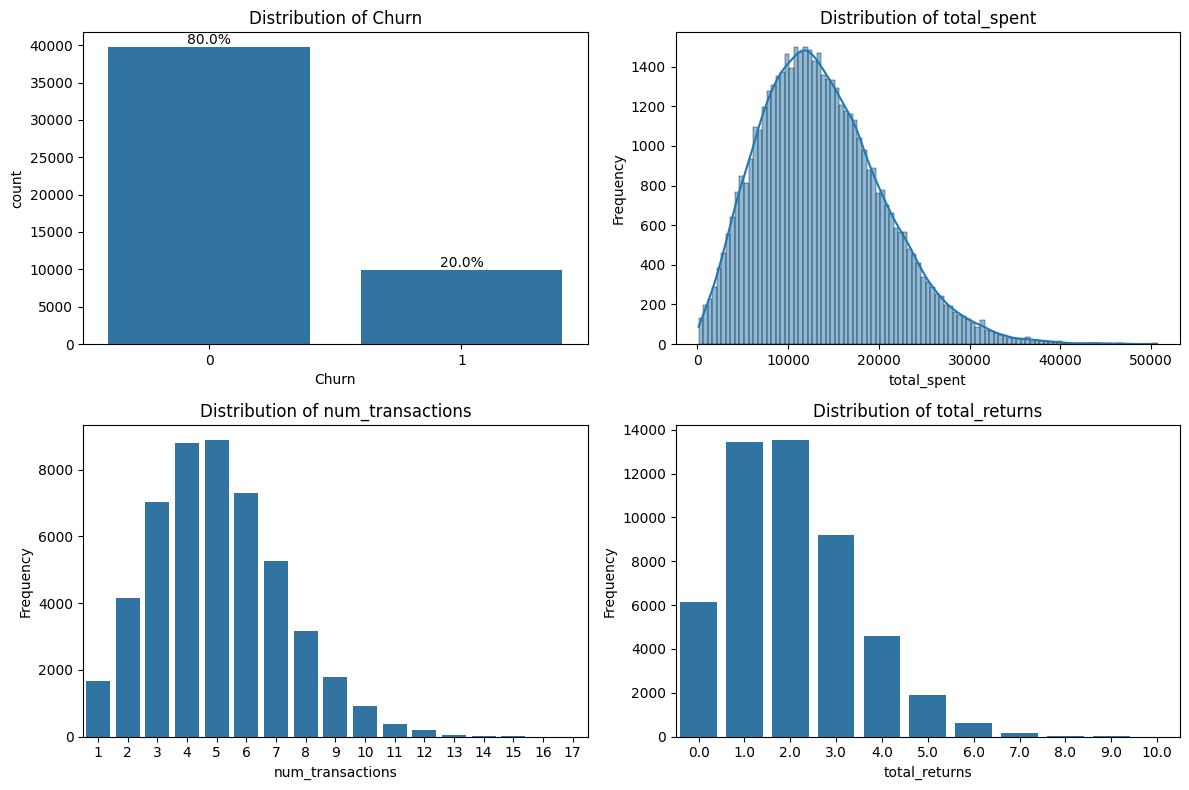

In [85]:
# EDA: Customer-Level Analysis 
df_customer = df.copy()

# fix types
df_customer['Purchase Date'] = pd.to_datetime(df_customer['Purchase Date'])
df_customer['Returns'] = df_customer['Returns'].fillna(0)

# aggregate to customer level
df_customer = df_customer.groupby('Customer ID').agg({
    'Total Purchase Amount': 'sum',
    'Purchase Date': 'count',
    'Returns': 'sum',
    'Churn': 'max',
}).rename(columns={
    'Total Purchase Amount': 'total_spent',
    'Purchase Date': 'num_transactions',
    'Returns': 'total_returns'
})

print(df_customer.head(2), '\n\n')


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = ['total_spent', 'num_transactions', 'total_returns']

# dynamic grid
n_plots = len(numerical_features) + 1
cols = 2
rows = (n_plots + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

# 1. Churn distribution
sns.countplot(x="Churn", data=df_customer, ax=axes[0])
axes[0].set_title("Distribution of Churn")

# add percentages
total = len(df_customer)
for p in axes[0].patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    axes[0].text(p.get_x() + p.get_width()/2, height, percentage,
                 ha='center', va='bottom')

# 2. Numerical distributions
for idx, feature in enumerate(numerical_features):
    ax = axes[idx + 1]
    
    if df_customer[feature].nunique() > 20:
        sns.histplot(df_customer[feature], kde=True, ax=ax)
    else:
        sns.countplot(x=feature, data=df_customer, ax=ax)
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

# remove empty plots
for i in range(len(numerical_features) + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Class Imbalance & skewed distribution

In [86]:
#custome age analysis and gender analysis

In [87]:
#product analysis

In [88]:
#payment method analysis

In [89]:
#returns analysis

In [90]:
# time series analysis

In [91]:
df_model=df.copy()